# Formal cross-condition statistics

In [ ]:
import pandas as pd
from pathlib import Path

csv_path = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "final_results/data/"
    "cross_condition_cross_seed_master.csv"
)

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nRows:")
display(df)

Shape: (16, 20)

Columns:
['condition', 'seed', 'generation', 'disease_f1', 'chemical_f1', 'disease_retention', 'chemical_retention', 'context_supported_rate', 'context_unsupported_rate', 'bleu_1', 'bleu_4', 'rouge_l', 'meteor', 'chrf_pp', 'bertscore_f1', 'cosine_similarity', 'word_count', 'token_count', 'repetition_rate', 'perplexity']

Rows:


,condition,seed,generation,disease_f1,chemical_f1,disease_retention,chemical_retention,context_supported_rate,context_unsupported_rate,bleu_1,bleu_4,rouge_l,meteor,chrf_pp,bertscore_f1,cosine_similarity,word_count,token_count,repetition_rate,perplexity
0,Recursive,42,G0,0.232436,0.232477,0.244208,0.258170,0.511150,0.488850,0.150407,0.013325,0.175726,0.155217,25.801892,0.874431,0.708696,36.749,45.121,0.000327,10.030342
1,Recursive,42,G1,0.184716,0.222948,0.200698,0.223312,0.404189,0.595811,0.130510,0.010687,0.151140,0.137216,24.736265,0.867554,0.678159,39.549,47.728,0.000123,13.342574
2,Recursive,42,G2,0.140183,0.185755,0.147790,0.199346,0.373968,0.626032,0.117960,0.009405,0.137318,0.126551,24.021216,0.862507,0.659102,42.658,51.501,0.000056,16.934232
3,Recursive,42,G3,0.132544,0.137255,0.141593,0.144880,0.319280,0.680720,0.107957,0.008432,0.127906,0.118652,23.328943,0.858568,0.641493,42.369,51.677,0.000034,20.431621
4,Recursive,123,G0,0.239688,0.217554,0.251955,0.223856,0.492288,0.507712,0.148616,0.012870,0.176268,0.154720,25.704085,0.874531,0.706115,36.550,44.557,0.000210,10.306921
5,Recursive,123,G1,0.202763,0.223981,0.212341,0.238017,0.454716,0.545284,0.133679,0.010840,0.152756,0.139179,24.888666,0.868205,0.680724,40.185,48.430,0.000178,12.992213
6,Recursive,123,G2,0.146039,0.189013,0.157077,0.200436,0.394707,0.605293,0.119231,0.009190,0.138283,0.127107,24.082774,0.864065,0.654671,42.313,50.255,0.000017,16.882717
7,Recursive,123,G3,0.137951,0.141285,0.148192,0.149782,0.354312,0.645688,0.111480,0.008311,0.131635,0.119916,23.623928,0.860213,0.647091,42.501,51.368,0.000097,19.588159
8,Human_Control,42,G0,0.232436,0.232477,0.244208,0.258170,0.511150,0.488850,0.150407,0.013325,0.175726,0.155217,25.801892,0.874431,0.708696,36.749,45.121,0.000327,10.030342
9,Human_Control,42,G1,0.243752,0.239216,0.260816,0.258715,0.540394,0.459606,0.154081,0.012506,0.175917,0.157624,26.515718,0.870919,0.708370,38.656,48.379,0.000427,14.348654


In [ ]:
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

All columns:
1. condition
2. seed
3. generation
4. disease_f1
5. chemical_f1
6. disease_retention
7. chemical_retention
8. context_supported_rate
9. context_unsupported_rate
10. bleu_1
11. bleu_4
12. rouge_l
13. meteor
14. chrf_pp
15. bertscore_f1
16. cosine_similarity
17. word_count
18. token_count
19. repetition_rate
20. perplexity


In [ ]:
metrics = [
    "disease_f1",
    "chemical_f1",
    "rouge_l",
    "bertscore_f1",
    "cosine_similarity",
    "word_count",
    "repetition_rate",
    "perplexity"
]

g0 = df[df["generation"] == "G0"].set_index(["condition", "seed"])
g3 = df[df["generation"] == "G3"].set_index(["condition", "seed"])

delta = g3[metrics] - g0[metrics]
delta = delta.reset_index()

print("G0 → G3 change:")
display(delta)

G0 → G3 change:


,condition,seed,disease_f1,chemical_f1,rouge_l,bertscore_f1,cosine_similarity,word_count,repetition_rate,perplexity
0,Recursive,42,-0.099892,-0.095223,-0.047820,-0.015863,-0.067203,5.620,-0.000293,10.401279
1,Recursive,123,-0.101737,-0.076268,-0.044633,-0.014317,-0.059024,5.951,-0.000112,9.281238
2,Human_Control,42,-0.007357,0.050996,-0.004734,-0.011081,-0.021519,3.543,0.000417,11.915831
3,Human_Control,123,-0.011310,0.017087,-0.007745,-0.012987,-0.021546,4.873,0.000212,11.791460


In [ ]:
# Difference-in-differences: Recursive change minus Human Control change

recursive = delta[delta["condition"] == "Recursive"].set_index("seed")
control = delta[delta["condition"] == "Human_Control"].set_index("seed")

did = recursive[metrics] - control[metrics]

print("Difference-in-differences (Recursive − Human Control):")
display(did)

Difference-in-differences (Recursive − Human Control):


,disease_f1,chemical_f1,rouge_l,bertscore_f1,cosine_similarity,word_count,repetition_rate,perplexity
seed,,,,,,,,
42,-0.092534,-0.146218,-0.043086,-0.004782,-0.045684,2.077,-0.000710,-1.514552
123,-0.090427,-0.093355,-0.036889,-0.001330,-0.037478,1.078,-0.000325,-2.510222


In [ ]:
stats_path = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "final_results/data/"
    "cross_condition_cross_seed_paired_statistical_analysis_master.csv"
)

stats_df = pd.read_csv(stats_path)

print("Shape:", stats_df.shape)
print("\nColumns:")
for i, col in enumerate(stats_df.columns, 1):
    print(f"{i}. {col}")

Shape: (272, 11)

Columns:
1. condition
2. seed
3. metric
4. comparison
5. n
6. mean_change
7. ci_95_low
8. ci_95_high
9. relative_change_percent
10. cohens_dz
11. wilcoxon_p


In [ ]:
print("Comparisons available:")
display(
    stats_df["comparison"]
    .value_counts()
    .sort_index()
)

Comparisons available:


,count
comparison,
G0 → G1,68
G0 → G3,68
G1 → G2,68
G2 → G3,68


In [ ]:
print("Metrics included in statistical analysis:")
display(
    stats_df["metric"]
    .value_counts()
    .sort_index()
)

Metrics included in statistical analysis:


,count
metric,
3-gram repetition,16
Average tokens,16
Average words,16
BERTScore F1,16
BLEU-1,16
BLEU-4,16
Chemical F1,16
Chemical retention,16
Context-supported rate,16


In [ ]:
important_metrics = [
    "Disease F1",
    "Chemical F1",
    "ROUGE-L",
    "BERTScore F1",
    "Cosine similarity",
    "Perplexity"
]

g0_g3_stats = stats_df[
    (stats_df["comparison"] == "G0 → G3") &
    (stats_df["metric"].isin(important_metrics))
].copy()

g0_g3_stats = g0_g3_stats.sort_values(
    ["metric", "condition", "seed"]
)

display(g0_g3_stats)

,condition,seed,metric,comparison,n,mean_change,ci_95_low,ci_95_high,relative_change_percent,cohens_dz,wilcoxon_p
183,Human_Control,42,BERTScore F1,G0 → G3,1000,-0.011081,-0.012606,-0.009599,-1.267224,-0.453905,3.544849e-48
251,Human_Control,123,BERTScore F1,G0 → G3,1000,-0.012987,-0.014456,-0.011558,-1.485045,-0.554678,1.112043e-68
47,Recursive,42,BERTScore F1,G0 → G3,1000,-0.015863,-0.017324,-0.014468,-1.814096,-0.691144,3.404025e-103
115,Recursive,123,BERTScore F1,G0 → G3,1000,-0.014317,-0.015544,-0.013115,-1.637142,-0.735400,6.352175e-100
143,Human_Control,42,Chemical F1,G0 → G3,31,-0.035330,-0.107220,0.033333,-4.201681,-0.175159,2.787921e-01
211,Human_Control,123,Chemical F1,G0 → G3,25,-0.080000,-0.154700,-0.012000,-9.630819,-0.424264,3.604930e-02
7,Recursive,42,Chemical F1,G0 → G3,15,0.066667,-0.022222,0.155556,8.000000,0.378932,1.118355e-01
75,Recursive,123,Chemical F1,G0 → G3,16,-0.076042,-0.168750,0.017708,-9.656085,-0.385241,1.434326e-01
187,Human_Control,42,Cosine similarity,G0 → G3,1000,-0.021519,-0.030610,-0.012377,-3.036395,-0.147223,4.676221e-06
255,Human_Control,123,Cosine similarity,G0 → G3,1000,-0.021546,-0.030581,-0.012337,-3.051415,-0.147522,6.337123e-07


In [ ]:
from pathlib import Path

base = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
)

print("CSV files under 0.5B evaluation:")
for p in sorted(base.rglob("*.csv")):
    print(p.relative_to(base))

CSV files under 0.5B evaluation:
final_results/data/cross_condition_cross_seed_entity_micro_bootstrap_statistics_master.csv
final_results/data/cross_condition_cross_seed_entity_micro_summary_master.csv
final_results/data/cross_condition_cross_seed_master.csv
final_results/data/cross_condition_cross_seed_paired_statistical_analysis_master.csv
final_results/data/micro_f1_generation_means.csv


In [ ]:
from pathlib import Path

project_root = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
)

matches = []

for p in project_root.rglob("*"):
    if p.is_file() and (
        "per_sample" in p.name.lower()
        or "domain_behavioral" in p.name.lower()
        or "context_support" in p.name.lower()
    ):
        matches.append(p)

print("Matching files:", len(matches))

for p in matches:
    print(p.relative_to(project_root))

Matching files: 0


In [ ]:
from pathlib import Path

content = Path("/content")

patterns = [
    "combined_lexical_semantic_domain_per_sample.csv",
    "combined_domain_behavioral_per_sample.csv",
]

found = []

for p in content.rglob("*"):
    if p.is_file() and p.name in patterns:
        found.append(p)

print("Found:", len(found))

for p in found:
    print(p)

Found: 0


In [ ]:
from pathlib import Path

for p in sorted(Path("/mnt/data").glob("*0.5B*")):
    print(p)

In [ ]:
from pathlib import Path

p = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "combined_evaluation_seed42_0.5b_colab.ipynb"
)

print("Exists:", p.exists())
print("Path:", p)

Exists: True
Path: /content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-0.5b/combined_evaluation_seed42_0.5b_colab.ipynb


In [ ]:
from pathlib import Path

root = Path("/content")

print("Files directly under /content:")
for p in sorted(root.iterdir()):
    print(p.name)

Files directly under /content:
.config
recursive-llm-degradation-research-main.zip
recursive_project
sample_data


In [ ]:
from pathlib import Path

root = Path("/content/recursive_project")

for p in root.rglob("*.csv"):
    print(p)

/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_entity_micro_bootstrap_statistics_master.csv
/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_paired_statistical_analysis_master.csv
/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_master.csv
/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-3b/final_results/data/micro_f1_generation_means.csv
/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_entity_micro_summary_master.csv
/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-0.5b/final_results/data/cross_condition_cross_see

In [ ]:
from zipfile import ZipFile
from pathlib import Path

zip_path = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "final_results/data.zip"
)

print("Exists:", zip_path.exists())

with ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Files inside data.zip:", len(files))

for f in files:
    print(f)

Exists: True
Files inside data.zip: 12
data/
__MACOSX/._data
data/cross_condition_cross_seed_entity_micro_bootstrap_statistics_master.csv
__MACOSX/data/._cross_condition_cross_seed_entity_micro_bootstrap_statistics_master.csv
data/cross_condition_cross_seed_paired_statistical_analysis_master.csv
__MACOSX/data/._cross_condition_cross_seed_paired_statistical_analysis_master.csv
data/cross_condition_cross_seed_master.csv
__MACOSX/data/._cross_condition_cross_seed_master.csv
data/micro_f1_generation_means.csv
__MACOSX/data/._micro_f1_generation_means.csv
data/cross_condition_cross_seed_entity_micro_summary_master.csv
__MACOSX/data/._cross_condition_cross_seed_entity_micro_summary_master.csv


In [ ]:
from pathlib import Path

for p in sorted(Path("/content").rglob("*.zip")):
    print(p)

/content/recursive-llm-degradation-research-main.zip
/content/recursive_project/recursive-llm-degradation-research-main/notebooks/evaluation_qwen2.5-0.5b/final_results/data.zip


In [ ]:
from pathlib import Path
import pandas as pd

path_3b = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-3b/"
    "final_results/data/"
    "cross_condition_cross_seed_master.csv"
)

df_3b = pd.read_csv(path_3b)

print("0.5B shape:", df.shape)
print("3B shape :", df_3b.shape)

print("\n0.5B columns:")
print(df.columns.tolist())

print("\n3B columns:")
print(df_3b.columns.tolist())

print("\n0.5B conditions:")
print(df["condition"].value_counts())

print("\n3B conditions:")
print(df_3b["condition"].value_counts())

print("\n0.5B generations:")
print(sorted(df["generation"].unique()))

print("\n3B generations:")
print(sorted(df_3b["generation"].unique()))

0.5B shape: (16, 20)
3B shape : (16, 20)

0.5B columns:
['condition', 'seed', 'generation', 'disease_f1', 'chemical_f1', 'disease_retention', 'chemical_retention', 'context_supported_rate', 'context_unsupported_rate', 'bleu_1', 'bleu_4', 'rouge_l', 'meteor', 'chrf_pp', 'bertscore_f1', 'cosine_similarity', 'word_count', 'token_count', 'repetition_rate', 'perplexity']

3B columns:
['condition', 'seed', 'generation', 'disease_f1', 'chemical_f1', 'disease_retention', 'chemical_retention', 'context_supported_rate', 'context_unsupported_rate', 'bleu_1', 'bleu_4', 'rouge_l', 'meteor', 'chrf_pp', 'bertscore_f1', 'cosine_similarity', 'word_count', 'token_count', 'repetition_rate', 'perplexity']

0.5B conditions:
condition
Recursive        8
Human_Control    8
Name: count, dtype: int64

3B conditions:
condition
Recursive        8
Human_Control    8
Name: count, dtype: int64

0.5B generations:
['G0', 'G1', 'G2', 'G3']

3B generations:
['G0', 'G1', 'G2', 'G3']


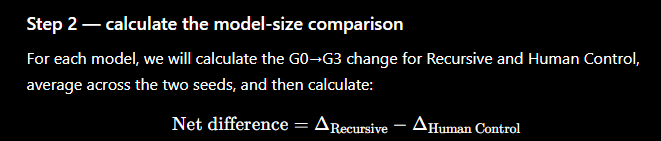

In [ ]:
metrics_core = [
    "disease_f1",
    "chemical_f1",
    "context_supported_rate",
    "context_unsupported_rate",
    "rouge_l",
    "bertscore_f1",
    "cosine_similarity",
    "word_count",
    "repetition_rate",
    "perplexity"
]

def calculate_model_deltas(data, model_name):
    g0 = data[data["generation"] == "G0"].set_index(["condition", "seed"])
    g3 = data[data["generation"] == "G3"].set_index(["condition", "seed"])

    delta = g3[metrics_core] - g0[metrics_core]

    rows = []

    for condition in ["Recursive", "Human_Control"]:
        values = delta.loc[condition]

        for metric in metrics_core:
            rows.append({
                "model": model_name,
                "condition": condition,
                "metric": metric,
                "mean_delta": values[metric].mean(),
                "seed42_delta": values.loc[42, metric],
                "seed123_delta": values.loc[123, metric],
            })

    return pd.DataFrame(rows)


delta_05b = calculate_model_deltas(df, "Qwen2.5-0.5B")
delta_3b = calculate_model_deltas(df_3b, "Qwen2.5-3B")

model_deltas = pd.concat(
    [delta_05b, delta_3b],
    ignore_index=True
)

display(model_deltas)

,model,condition,metric,mean_delta,seed42_delta,seed123_delta
0,Qwen2.5-0.5B,Recursive,disease_f1,-0.100814,-0.099892,-0.101737
1,Qwen2.5-0.5B,Recursive,chemical_f1,-0.085745,-0.095223,-0.076268
2,Qwen2.5-0.5B,Recursive,context_supported_rate,-0.164923,-0.191869,-0.137976
3,Qwen2.5-0.5B,Recursive,context_unsupported_rate,0.164923,0.191869,0.137976
4,Qwen2.5-0.5B,Recursive,rouge_l,-0.046227,-0.047820,-0.044633
5,Qwen2.5-0.5B,Recursive,bertscore_f1,-0.015090,-0.015863,-0.014317
6,Qwen2.5-0.5B,Recursive,cosine_similarity,-0.063113,-0.067203,-0.059024
7,Qwen2.5-0.5B,Recursive,word_count,5.785500,5.620000,5.951000
8,Qwen2.5-0.5B,Recursive,repetition_rate,-0.000203,-0.000293,-0.000112
9,Qwen2.5-0.5B,Recursive,perplexity,9.841259,10.401279,9.281238


In [ ]:
# Calculate the Recursive-vs-Control effect for each model
# and then compare that effect between 0.5B and 3B.

effect_rows = []

for model in ["Qwen2.5-0.5B", "Qwen2.5-3B"]:
    rec = model_deltas[
        (model_deltas["model"] == model) &
        (model_deltas["condition"] == "Recursive")
    ].set_index("metric")

    ctrl = model_deltas[
        (model_deltas["model"] == model) &
        (model_deltas["condition"] == "Human_Control")
    ].set_index("metric")

    for metric in metrics_core:
        rec_delta = rec.loc[metric, "mean_delta"]
        ctrl_delta = ctrl.loc[metric, "mean_delta"]

        effect_rows.append({
            "model": model,
            "metric": metric,
            "recursive_delta": rec_delta,
            "control_delta": ctrl_delta,
            "recursive_minus_control": rec_delta - ctrl_delta
        })

effects = pd.DataFrame(effect_rows)

# Compare model-size effects
effect_05b = effects[
    effects["model"] == "Qwen2.5-0.5B"
].set_index("metric")

effect_3b = effects[
    effects["model"] == "Qwen2.5-3B"
].set_index("metric")

model_size_comparison = pd.DataFrame({
    "effect_0.5B": effect_05b["recursive_minus_control"],
    "effect_3B": effect_3b["recursive_minus_control"],
})

model_size_comparison["3B_minus_0.5B"] = (
    model_size_comparison["effect_3B"]
    - model_size_comparison["effect_0.5B"]
)

display(model_size_comparison)

,effect_0.5B,effect_3B,3B_minus_0.5B
metric,,,
disease_f1,-0.091481,-0.144443,-0.052962
chemical_f1,-0.119787,-0.130208,-0.010421
context_supported_rate,-0.218735,-0.326795,-0.108060
context_unsupported_rate,0.218735,0.326795,0.108060
rouge_l,-0.039988,-0.062049,-0.022062
bertscore_f1,-0.003056,-0.017525,-0.014469
cosine_similarity,-0.041581,-0.066285,-0.024704
word_count,1.577500,22.822500,21.245000
repetition_rate,-0.000517,-0.000375,0.000142


In [ ]:
# Seed-level Recursive-vs-Control effects for each model

seed_effect_rows = []

for model in ["Qwen2.5-0.5B", "Qwen2.5-3B"]:
    for seed in [42, 123]:

        rec = model_deltas[
            (model_deltas["model"] == model) &
            (model_deltas["condition"] == "Recursive")
        ].set_index("metric")

        ctrl = model_deltas[
            (model_deltas["model"] == model) &
            (model_deltas["condition"] == "Human_Control")
        ].set_index("metric")

        # Retrieve the seed-specific G0->G3 changes
        for metric in metrics_core:
            rec_delta = rec.loc[metric, f"seed{seed}_delta"]
            ctrl_delta = ctrl.loc[metric, f"seed{seed}_delta"]

            seed_effect_rows.append({
                "model": model,
                "seed": seed,
                "metric": metric,
                "recursive_minus_control": rec_delta - ctrl_delta
            })

seed_effects = pd.DataFrame(seed_effect_rows)

display(seed_effects)

,model,seed,metric,recursive_minus_control
0,Qwen2.5-0.5B,42,disease_f1,-0.092534
1,Qwen2.5-0.5B,42,chemical_f1,-0.146218
2,Qwen2.5-0.5B,42,context_supported_rate,-0.248108
3,Qwen2.5-0.5B,42,context_unsupported_rate,0.248108
4,Qwen2.5-0.5B,42,rouge_l,-0.043086
5,Qwen2.5-0.5B,42,bertscore_f1,-0.004782
6,Qwen2.5-0.5B,42,cosine_similarity,-0.045684
7,Qwen2.5-0.5B,42,word_count,2.077000
8,Qwen2.5-0.5B,42,repetition_rate,-0.000710
9,Qwen2.5-0.5B,42,perplexity,-1.514552


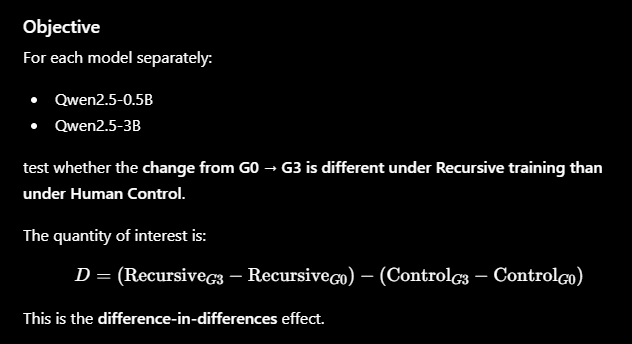

# Final Statistical Synthesis
This section consolidates the completed 0.5B and 3B master results. It separates within-condition G0→G3 inference already computed in the project from the Recursive-versus-Human-Control effect magnitude and the model-size interaction, which are descriptive across the two tested seeds.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/content/recursive_project/recursive-llm-degradation-research-main/notebooks")
MASTER_05B = ROOT / "evaluation_qwen2.5-0.5b/final_results/data/cross_condition_cross_seed_master.csv"
MASTER_3B = ROOT / "evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_master.csv"
STATS_05B = ROOT / "evaluation_qwen2.5-0.5b/final_results/data/cross_condition_cross_seed_paired_statistical_analysis_master.csv"
STATS_3B = ROOT / "evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_paired_statistical_analysis_master.csv"

master_05b = pd.read_csv(MASTER_05B)
master_3b = pd.read_csv(MASTER_3B)
stats_05b = pd.read_csv(STATS_05B)
stats_3b = pd.read_csv(STATS_3B)

print("0.5B master:", master_05b.shape)
print("3B master :", master_3b.shape)
print("0.5B stats:", stats_05b.shape)
print("3B stats :", stats_3b.shape)

0.5B master: (16, 20)
3B master : (16, 20)
0.5B stats: (272, 11)
3B stats : (272, 11)


In [ ]:
CORE_METRICS = [
    "disease_f1", "chemical_f1",
    "context_supported_rate", "context_unsupported_rate",
    "rouge_l", "bertscore_f1", "cosine_similarity",
    "word_count", "repetition_rate", "perplexity"
]

def g0_g3_effects(master, model_name):
    g0 = master[master["generation"] == "G0"].set_index(["condition", "seed"])
    g3 = master[master["generation"] == "G3"].set_index(["condition", "seed"])
    delta = g3[CORE_METRICS] - g0[CORE_METRICS]
    rows = []
    for metric in CORE_METRICS:
        rec = delta.loc["Recursive", metric]
        ctrl = delta.loc["Human_Control", metric]
        d = rec - ctrl
        rows.append({
            "model": model_name,
            "metric": metric,
            "recursive_mean_delta": rec.mean(),
            "control_mean_delta": ctrl.mean(),
            "recursive_minus_control": d.mean(),
            "seed42_effect": d.loc[42],
            "seed123_effect": d.loc[123],
        })
    return pd.DataFrame(rows)

condition_effects = pd.concat([
    g0_g3_effects(master_05b, "Qwen2.5-0.5B"),
    g0_g3_effects(master_3b, "Qwen2.5-3B"),
], ignore_index=True)

display(condition_effects.round(6))

,model,metric,recursive_mean_delta,control_mean_delta,recursive_minus_control,seed42_effect,seed123_effect
0,Qwen2.5-0.5B,disease_f1,-0.100814,-0.009334,-0.091481,-0.092534,-0.090427
1,Qwen2.5-0.5B,chemical_f1,-0.085745,0.034041,-0.119787,-0.146218,-0.093355
2,Qwen2.5-0.5B,context_supported_rate,-0.164923,0.053812,-0.218735,-0.248108,-0.189362
3,Qwen2.5-0.5B,context_unsupported_rate,0.164923,-0.053812,0.218735,0.248108,0.189362
4,Qwen2.5-0.5B,rouge_l,-0.046227,-0.006239,-0.039988,-0.043086,-0.036889
5,Qwen2.5-0.5B,bertscore_f1,-0.015090,-0.012034,-0.003056,-0.004782,-0.001330
6,Qwen2.5-0.5B,cosine_similarity,-0.063113,-0.021533,-0.041581,-0.045684,-0.037478
7,Qwen2.5-0.5B,word_count,5.785500,4.208000,1.577500,2.077000,1.078000
8,Qwen2.5-0.5B,repetition_rate,-0.000203,0.000315,-0.000517,-0.000710,-0.000325
9,Qwen2.5-0.5B,perplexity,9.841259,11.853646,-2.012387,-1.514552,-2.510222


In [ ]:
wide = condition_effects.pivot(index="metric", columns="model", values="recursive_minus_control")
wide["3B_minus_0.5B"] = wide["Qwen2.5-3B"] - wide["Qwen2.5-0.5B"]

seed42_wide = condition_effects.pivot(index="metric", columns="model", values="seed42_effect")
seed42_interaction = seed42_wide["Qwen2.5-3B"] - seed42_wide["Qwen2.5-0.5B"]

seed123_wide = condition_effects.pivot(index="metric", columns="model", values="seed123_effect")
seed123_interaction = seed123_wide["Qwen2.5-3B"] - seed123_wide["Qwen2.5-0.5B"]

model_size_interaction = wide[["Qwen2.5-0.5B", "Qwen2.5-3B", "3B_minus_0.5B"]].copy()
model_size_interaction["seed42_interaction"] = seed42_interaction
model_size_interaction["seed123_interaction"] = seed123_interaction

display(model_size_interaction.round(6))

model,Qwen2.5-0.5B,Qwen2.5-3B,3B_minus_0.5B,seed42_interaction,seed123_interaction
metric,,,,,
bertscore_f1,-0.003056,-0.017525,-0.014469,-0.014540,-0.014398
chemical_f1,-0.119787,-0.130208,-0.010421,-0.018669,-0.002173
context_supported_rate,-0.218735,-0.326795,-0.108060,-0.118846,-0.097274
context_unsupported_rate,0.218735,0.326795,0.108060,0.118846,0.097274
cosine_similarity,-0.041581,-0.066285,-0.024704,-0.013111,-0.036297
disease_f1,-0.091481,-0.144443,-0.052962,-0.035494,-0.070430
perplexity,-2.012387,4.505007,6.517394,5.853479,7.181308
repetition_rate,-0.000517,-0.000375,0.000142,0.000394,-0.000110
rouge_l,-0.039988,-0.062049,-0.022062,-0.019917,-0.024206


Existing within-condition inferential results
The project master statistical files already contain paired G0→G3 bootstrap confidence intervals, Cohen's dz, and Wilcoxon tests within each condition and seed. These p-values test generation change within a condition; they are not direct Recursive-vs-Control p-values.

In [ ]:
KEY_STAT_METRICS = [
    "Disease F1", "Chemical F1", "ROUGE-L",
    "BERTScore F1", "Cosine similarity", "Perplexity"
]

def select_g0_g3(stats, model_name):
    x = stats[(stats["comparison"] == "G0 → G3") & (stats["metric"].isin(KEY_STAT_METRICS))].copy()
    x.insert(0, "model", model_name)
    return x[["model", "condition", "seed", "metric", "n", "mean_change", "ci_95_low", "ci_95_high", "cohens_dz", "wilcoxon_p"]]

within_condition_inference = pd.concat([
    select_g0_g3(stats_05b, "Qwen2.5-0.5B"),
    select_g0_g3(stats_3b, "Qwen2.5-3B"),
], ignore_index=True)

display(within_condition_inference.sort_values(["metric", "model", "condition", "seed"]).round(6))

,model,condition,seed,metric,n,mean_change,ci_95_low,ci_95_high,cohens_dz,wilcoxon_p
15,Qwen2.5-0.5B,Human_Control,42,BERTScore F1,1000,-0.011081,-0.012606,-0.009599,-0.453905,0.000000
21,Qwen2.5-0.5B,Human_Control,123,BERTScore F1,1000,-0.012987,-0.014456,-0.011558,-0.554678,0.000000
3,Qwen2.5-0.5B,Recursive,42,BERTScore F1,1000,-0.015863,-0.017324,-0.014468,-0.691144,0.000000
9,Qwen2.5-0.5B,Recursive,123,BERTScore F1,1000,-0.014317,-0.015544,-0.013115,-0.735400,0.000000
39,Qwen2.5-3B,Human_Control,42,BERTScore F1,1000,-0.009658,-0.011313,-0.008054,-0.362032,0.000000
45,Qwen2.5-3B,Human_Control,123,BERTScore F1,1000,-0.010339,-0.012175,-0.008554,-0.356385,0.000000
27,Qwen2.5-3B,Recursive,42,BERTScore F1,1000,-0.028980,-0.030834,-0.027151,-0.960045,0.000000
33,Qwen2.5-3B,Recursive,123,BERTScore F1,1000,-0.026067,-0.027857,-0.024346,-0.919927,0.000000
13,Qwen2.5-0.5B,Human_Control,42,Chemical F1,31,-0.035330,-0.107220,0.033333,-0.175159,0.278792
19,Qwen2.5-0.5B,Human_Control,123,Chemical F1,25,-0.080000,-0.154700,-0.012000,-0.424264,0.036049


Interpretation guardrails
Within-condition inference: use the existing bootstrap CI / Wilcoxon / Cohen's dz values above to describe G0→G3 changes within Recursive or Human Control.
Recursive-vs-Control effect: use recursive_minus_control as the difference-in-differences effect magnitude.
Model-size interaction: use 3B_minus_0.5B as a descriptive interaction across the two tested seeds. With only two seeds per model, do not report a conventional population-level significance test for this interaction.
Do not treat within-condition Wilcoxon p-values as tests of the Recursive-versus-Control contrast.

In [ ]:
OUT = Path("/content/final_analysis")
OUT.mkdir(parents=True, exist_ok=True)
condition_effects.to_csv(OUT / "condition_effects_g0_g3.csv", index=False)
model_size_interaction.reset_index().to_csv(OUT / "model_size_interaction.csv", index=False)
within_condition_inference.to_csv(OUT / "within_condition_inference_g0_g3.csv", index=False)
print("Saved:", OUT)
for p in sorted(OUT.glob("*.csv")):
    print(p.name)

Saved: /content/final_analysis
condition_effects_g0_g3.csv
model_size_interaction.csv
within_condition_inference_g0_g3.csv


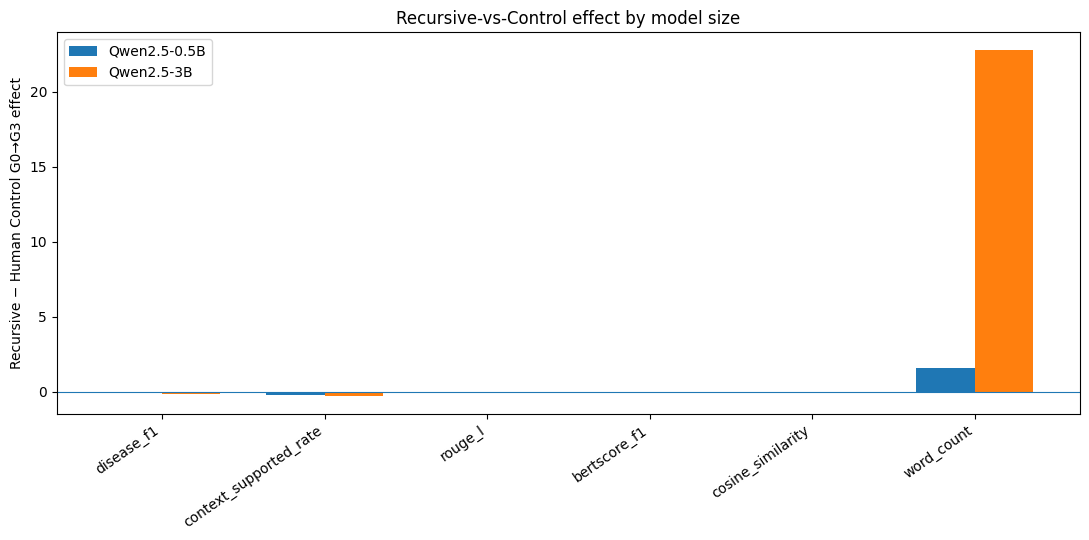

In [ ]:
import matplotlib.pyplot as plt

PLOT_METRICS = ["disease_f1", "context_supported_rate", "rouge_l", "bertscore_f1", "cosine_similarity", "word_count"]
plot_df = model_size_interaction.loc[PLOT_METRICS]
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(PLOT_METRICS))
width = 0.36
ax.bar(x - width/2, plot_df["Qwen2.5-0.5B"], width, label="Qwen2.5-0.5B")
ax.bar(x + width/2, plot_df["Qwen2.5-3B"], width, label="Qwen2.5-3B")
ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(PLOT_METRICS, rotation=35, ha="right")
ax.set_ylabel("Recursive − Human Control G0→G3 effect")
ax.set_title("Recursive-vs-Control effect by model size")
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import shutil
from google.colab import files

folder = Path("/content/final_analysis")

print("Folder exists:", folder.exists())
print("Contents:")
for p in folder.rglob("*"):
    print(p.relative_to(folder))

zip_path = shutil.make_archive(
    "/content/final_analysis",
    "zip",
    root_dir=folder
)

print("\nCreated:", zip_path)

files.download(zip_path)

Folder exists: True
Contents:
condition_effects_g0_g3.csv
within_condition_inference_g0_g3.csv
model_size_interaction.csv

Created: /content/final_analysis.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>